# Alive or Died from COVID 19

In [ ]:
# from google.colab import drive # colab
# drive.mount('/content/drive') # colab

Mounted at /content/drive


<div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="../images/covid.webp" width="400" height="250" style="border-radius:50%;">
    <img src="../images/earth.webp" width="400" height="250" style="border-radius:50%;">
</div>

## Importing

In [ ]:
import pandas as pd
pd.set_option ('display.precision', 2)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc

## Read the data
<a href= "https://www.kaggle.com/datasets/meirnizri/covid19-dataset/data">Source</a>

In [3]:
# df = pd.read_csv ("../data/covid.csv") # Local
df = pd.read_csv ("./drive/MyDrive/Projects/covid_19/data/covid.csv") # colab
num_of_actual_rows = df.shape [0]
df.shape

(1048575, 21)

### Over 1M records

## Understand and explore the data

In [4]:
df.head (10)

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97
5,2,1,1,2,9999-99-99,2,1,40,2,2,...,2,2,2,2,2,2,2,2,3,2
6,2,1,1,1,9999-99-99,97,2,64,2,2,...,2,2,2,2,2,2,2,2,3,97
7,2,1,1,1,9999-99-99,97,1,64,2,1,...,2,1,1,2,2,2,1,2,3,97
8,2,1,1,2,9999-99-99,2,2,37,2,1,...,2,2,1,2,2,1,2,2,3,2
9,2,1,1,2,9999-99-99,2,2,25,2,2,...,2,2,2,2,2,2,2,2,3,2


In [5]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  int64 
 1   MEDICAL_UNIT          1048575 non-null  int64 
 2   SEX                   1048575 non-null  int64 
 3   PATIENT_TYPE          1048575 non-null  int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  int64 
 6   PNEUMONIA             1048575 non-null  int64 
 7   AGE                   1048575 non-null  int64 
 8   PREGNANT              1048575 non-null  int64 
 9   DIABETES              1048575 non-null  int64 
 10  COPD                  1048575 non-null  int64 
 11  ASTHMA                1048575 non-null  int64 
 12  INMSUPR               1048575 non-null  int64 
 13  HIPERTENSION          1048575 non-null  int64 
 14  OTHER_DISEASE         1048575 non-null  int64 
 15

In [6]:
df.describe ()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06,1.05e+06
mean,1.63e+00,8.98e+00,1.50e+00,1.19e+00,7.95e+01,3.35e+00,4.18e+01,4.98e+01,2.19e+00,2.26e+00,2.24e+00,2.30e+00,2.13e+00,2.44e+00,2.26e+00,2.13e+00,2.26e+00,2.21e+00,5.31e+00,7.96e+01
std,4.82e-01,3.72e+00,5.00e-01,3.93e-01,3.69e+01,1.19e+01,1.69e+01,4.75e+01,5.42e+00,5.13e+00,5.11e+00,5.46e+00,5.24e+00,6.65e+00,5.19e+00,5.18e+00,5.14e+00,5.32e+00,1.88e+00,3.68e+01
min,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,0.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00
25%,1.00e+00,4.00e+00,1.00e+00,1.00e+00,9.70e+01,2.00e+00,3.00e+01,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,3.00e+00,9.70e+01
50%,2.00e+00,1.20e+01,1.00e+00,1.00e+00,9.70e+01,2.00e+00,4.00e+01,9.70e+01,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,6.00e+00,9.70e+01
75%,2.00e+00,1.20e+01,2.00e+00,1.00e+00,9.70e+01,2.00e+00,5.30e+01,9.70e+01,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,2.00e+00,7.00e+00,9.70e+01
max,2.00e+00,1.30e+01,2.00e+00,2.00e+00,9.90e+01,9.90e+01,1.21e+02,9.80e+01,9.80e+01,9.80e+01,9.80e+01,9.80e+01,9.80e+01,9.80e+01,9.80e+01,9.80e+01,9.80e+01,9.80e+01,7.00e+00,9.90e+01


<div align="center">
    <h1> Data description</h1>
    <img src= "../images/data_content.png" alt ="Data content from resource" height= "800">
</div>

### Rename the columns to be clear

In [7]:
for col in df.columns:
    print (f"Name: {col}")
    print (f"Len: {len (df [col].unique ())}")
    print (f"Values: {sorted (df [col].unique ().tolist ())[:15]}")
    print ('-' * 40)

Name: USMER
Len: 2
Values: [1, 2]
----------------------------------------
Name: MEDICAL_UNIT
Len: 13
Values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
----------------------------------------
Name: SEX
Len: 2
Values: [1, 2]
----------------------------------------
Name: PATIENT_TYPE
Len: 2
Values: [1, 2]
----------------------------------------
Name: DATE_DIED
Len: 401
Values: ['01/01/2021', '01/02/2020', '01/02/2021', '01/03/2020', '01/04/2020', '01/04/2021', '01/05/2020', '01/05/2021', '01/06/2020', '01/07/2020', '01/08/2020', '01/09/2020', '02/01/2020', '02/01/2021', '02/02/2020']
----------------------------------------
Name: INTUBED
Len: 4
Values: [1, 2, 97, 99]
----------------------------------------
Name: PNEUMONIA
Len: 3
Values: [1, 2, 99]
----------------------------------------
Name: AGE
Len: 121
Values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
----------------------------------------
Name: PREGNANT
Len: 4
Values: [1, 2, 97, 98]
---------------------------------

In [8]:
new_names = {
    "USMER" : "medical_unit_level", # the medical unit level.

    "MEDICAL_UNIT" : "medical_unit", # the medical institution (Like the name of this place)

    "SEX" : "gender", # Female (1) | Male (2)

    "PATIENT_TYPE" : "care_type", # Returned home (1) | Hospitalized (2)

    "DATE_DIED" : "death_date", # Date of death | 9999-99-99 = no death date

    "INTUBED" : "intubated", # used a ventilator -> Yes (1) | No (2) | nan (97, 99)

    "PNEUMONIA" : "pneumonia", # has pneumonia. Yes (1) | No (2) | nan (99)

    "AGE" : "age", # AGE

    "PREGNANT" : "pregnant", # Yes (1) | No (2) | nan (97, 98)

    "DIABETES" : "diabetes", # has diabetes. Yes (1) | No (2) | nan (98)

    "COPD" : "copd", # has COPD Yes (1) | No (2) | nan (98)

    "ASTHMA" : "asthma", # has ASTHMA Yes (1) | No (2) | nan (98)

    "INMSUPR" : "immunosuppressed", # has INMSUPR Yes (1) | No (2) | nan (98)

    "HIPERTENSION" : "high_pressure", # has High Blood Pressure  Yes (1) | No (2) | nan (98)

    "OTHER_DISEASE" : "other_disease", # has OTHER_DISEASE Yes (1) | No (2) | nan (98)

    "CARDIOVASCULAR" : "cardiovascular", # has cardiovascular Yes (1) | No (2) | nan (98)

    "OBESITY" : "obesity", # Yes (1) | No (2) | nan (98)

    "RENAL_CHRONIC" : "chronic_renal", # has RENAL_CHRONIC Yes (1) | No (2) | nan (98)

    "TOBACCO" : "tobacco_use", # Yes (1) | No (2) | nan (98)

    "CLASIFFICATION_FINAL" : "covid_classification", # Positive (1 : 3) | negative (4 : 7)

    "ICU" : "icu_admission" # was admitted to the ICU. Yes (1) | No (2) | nan (98)
}

In [9]:
df = df.rename (columns= new_names)
df.columns

Index(['medical_unit_level', 'medical_unit', 'gender', 'care_type',
       'death_date', 'intubated', 'pneumonia', 'age', 'pregnant', 'diabetes',
       'copd', 'asthma', 'immunosuppressed', 'high_pressure', 'other_disease',
       'cardiovascular', 'obesity', 'chronic_renal', 'tobacco_use',
       'covid_classification', 'icu_admission'],
      dtype='object')

### Make the target 🥅

In [10]:
df ['death_date'].value_counts ()

,count
death_date,
9999-99-99,971633
06/07/2020,1000
07/07/2020,996
13/07/2020,990
16/06/2020,979
...,...
25/12/2020,1
01/01/2021,1
02/01/2021,1


<div style="display:flex; gap:12px; align-items:center;">
    <div style="padding:10px 14px; border-radius:8px; background:#e6ffed; color:#087f3f; font-weight:600;">
        9999-99-99 -> Alive ✅
    </div>
    <div style="padding:10px 14px; border-radius:8px; background:#fff0f0; color:#b21b1b; font-weight:600;">
        Other -> Died 💀
    </div>
</div>

In [11]:
df ['DIED'] = df ['death_date'].apply (lambda x: 0 if x == '9999-99-99' else 1)

df = df.drop (columns= ['death_date'])
df.columns

Index(['medical_unit_level', 'medical_unit', 'gender', 'care_type',
       'intubated', 'pneumonia', 'age', 'pregnant', 'diabetes', 'copd',
       'asthma', 'immunosuppressed', 'high_pressure', 'other_disease',
       'cardiovascular', 'obesity', 'chronic_renal', 'tobacco_use',
       'covid_classification', 'icu_admission', 'DIED'],
      dtype='object')

In [12]:
df.duplicated ().sum ()

np.int64(836562)

### Duplicates -> Don't remove
`Why?` 👇

In [ ]:
features = df.drop (columns= "DIED")

duplicated_groups = (
    df.groupby (features.columns.tolist ()) ["DIED"].nunique ()
)

duplicated_groups.value_counts ()

,count
DIED,
1,182913
2,14550


In [14]:
df.isnull ().sum ().sum ()

np.int64(0)

In [15]:
df.nunique ()

,0
medical_unit_level,2
medical_unit,13
gender,2
care_type,2
intubated,4
pneumonia,3
age,121
pregnant,4
diabetes,3
copd,3


In [16]:
# binary_cols (0s - 1s)

binary_cols = ['gender', 'care_type', 'intubated', 'pneumonia', 'pregnant',
               'diabetes', 'copd', 'asthma', 'immunosuppressed', 'high_pressure',
               'other_disease', 'cardiovascular', 'obesity', 'chronic_renal',
               'tobacco_use', 'icu_admission']

for col in binary_cols:
    df [col] = df [col].replace ({
        1 : 1,
        2 : 0
        })

In [17]:
df [binary_cols] = df [binary_cols].replace ({
    97: np.nan,
    98: np.nan,
    99: np.nan
    })

In [18]:
df.isna ().sum ()

,0
medical_unit_level,0
medical_unit,0
gender,0
care_type,0
intubated,855869
pneumonia,16003
age,0
pregnant,527265
diabetes,3338
copd,3003


In [19]:
#for col in binary_cols:
#    mode = df [col].mode ()[0]
#    df [col] = df [col].fillna (value= mode)

In [20]:
df.loc[df['gender'] == 0, 'pregnant'] = 0

female_mode = df.loc[
    df['gender'] == 1, 'pregnant'
].mode()[0]

df.loc[
    (df['gender'] == 1) & (df['pregnant'].isna()),
    'pregnant'
] = female_mode

In [21]:
for col in ("icu_admission", "intubated"):
    mode = df [col].mode ()[0]
    df [col] = df [col].fillna (value= mode)


In [22]:
df.isna ().sum ()

,0
medical_unit_level,0
medical_unit,0
gender,0
care_type,0
intubated,0
pneumonia,16003
age,0
pregnant,0
diabetes,3338
copd,3003


In [23]:
df.shape

(1048575, 21)

In [24]:
df = df.dropna ()

In [25]:
print ("Shape After Handle nan", df.shape)
print ("Dropped:", num_of_actual_rows - df.shape [0])

Shape After Handle nan (1025152, 21)
Dropped: 23423


In [26]:
df.columns

Index(['medical_unit_level', 'medical_unit', 'gender', 'care_type',
       'intubated', 'pneumonia', 'age', 'pregnant', 'diabetes', 'copd',
       'asthma', 'immunosuppressed', 'high_pressure', 'other_disease',
       'cardiovascular', 'obesity', 'chronic_renal', 'tobacco_use',
       'covid_classification', 'icu_admission', 'DIED'],
      dtype='object')

### Explore binary columns

In [27]:
binary_cols

['gender',
 'care_type',
 'intubated',
 'pneumonia',
 'pregnant',
 'diabetes',
 'copd',
 'asthma',
 'immunosuppressed',
 'high_pressure',
 'other_disease',
 'cardiovascular',
 'obesity',
 'chronic_renal',
 'tobacco_use',
 'icu_admission']

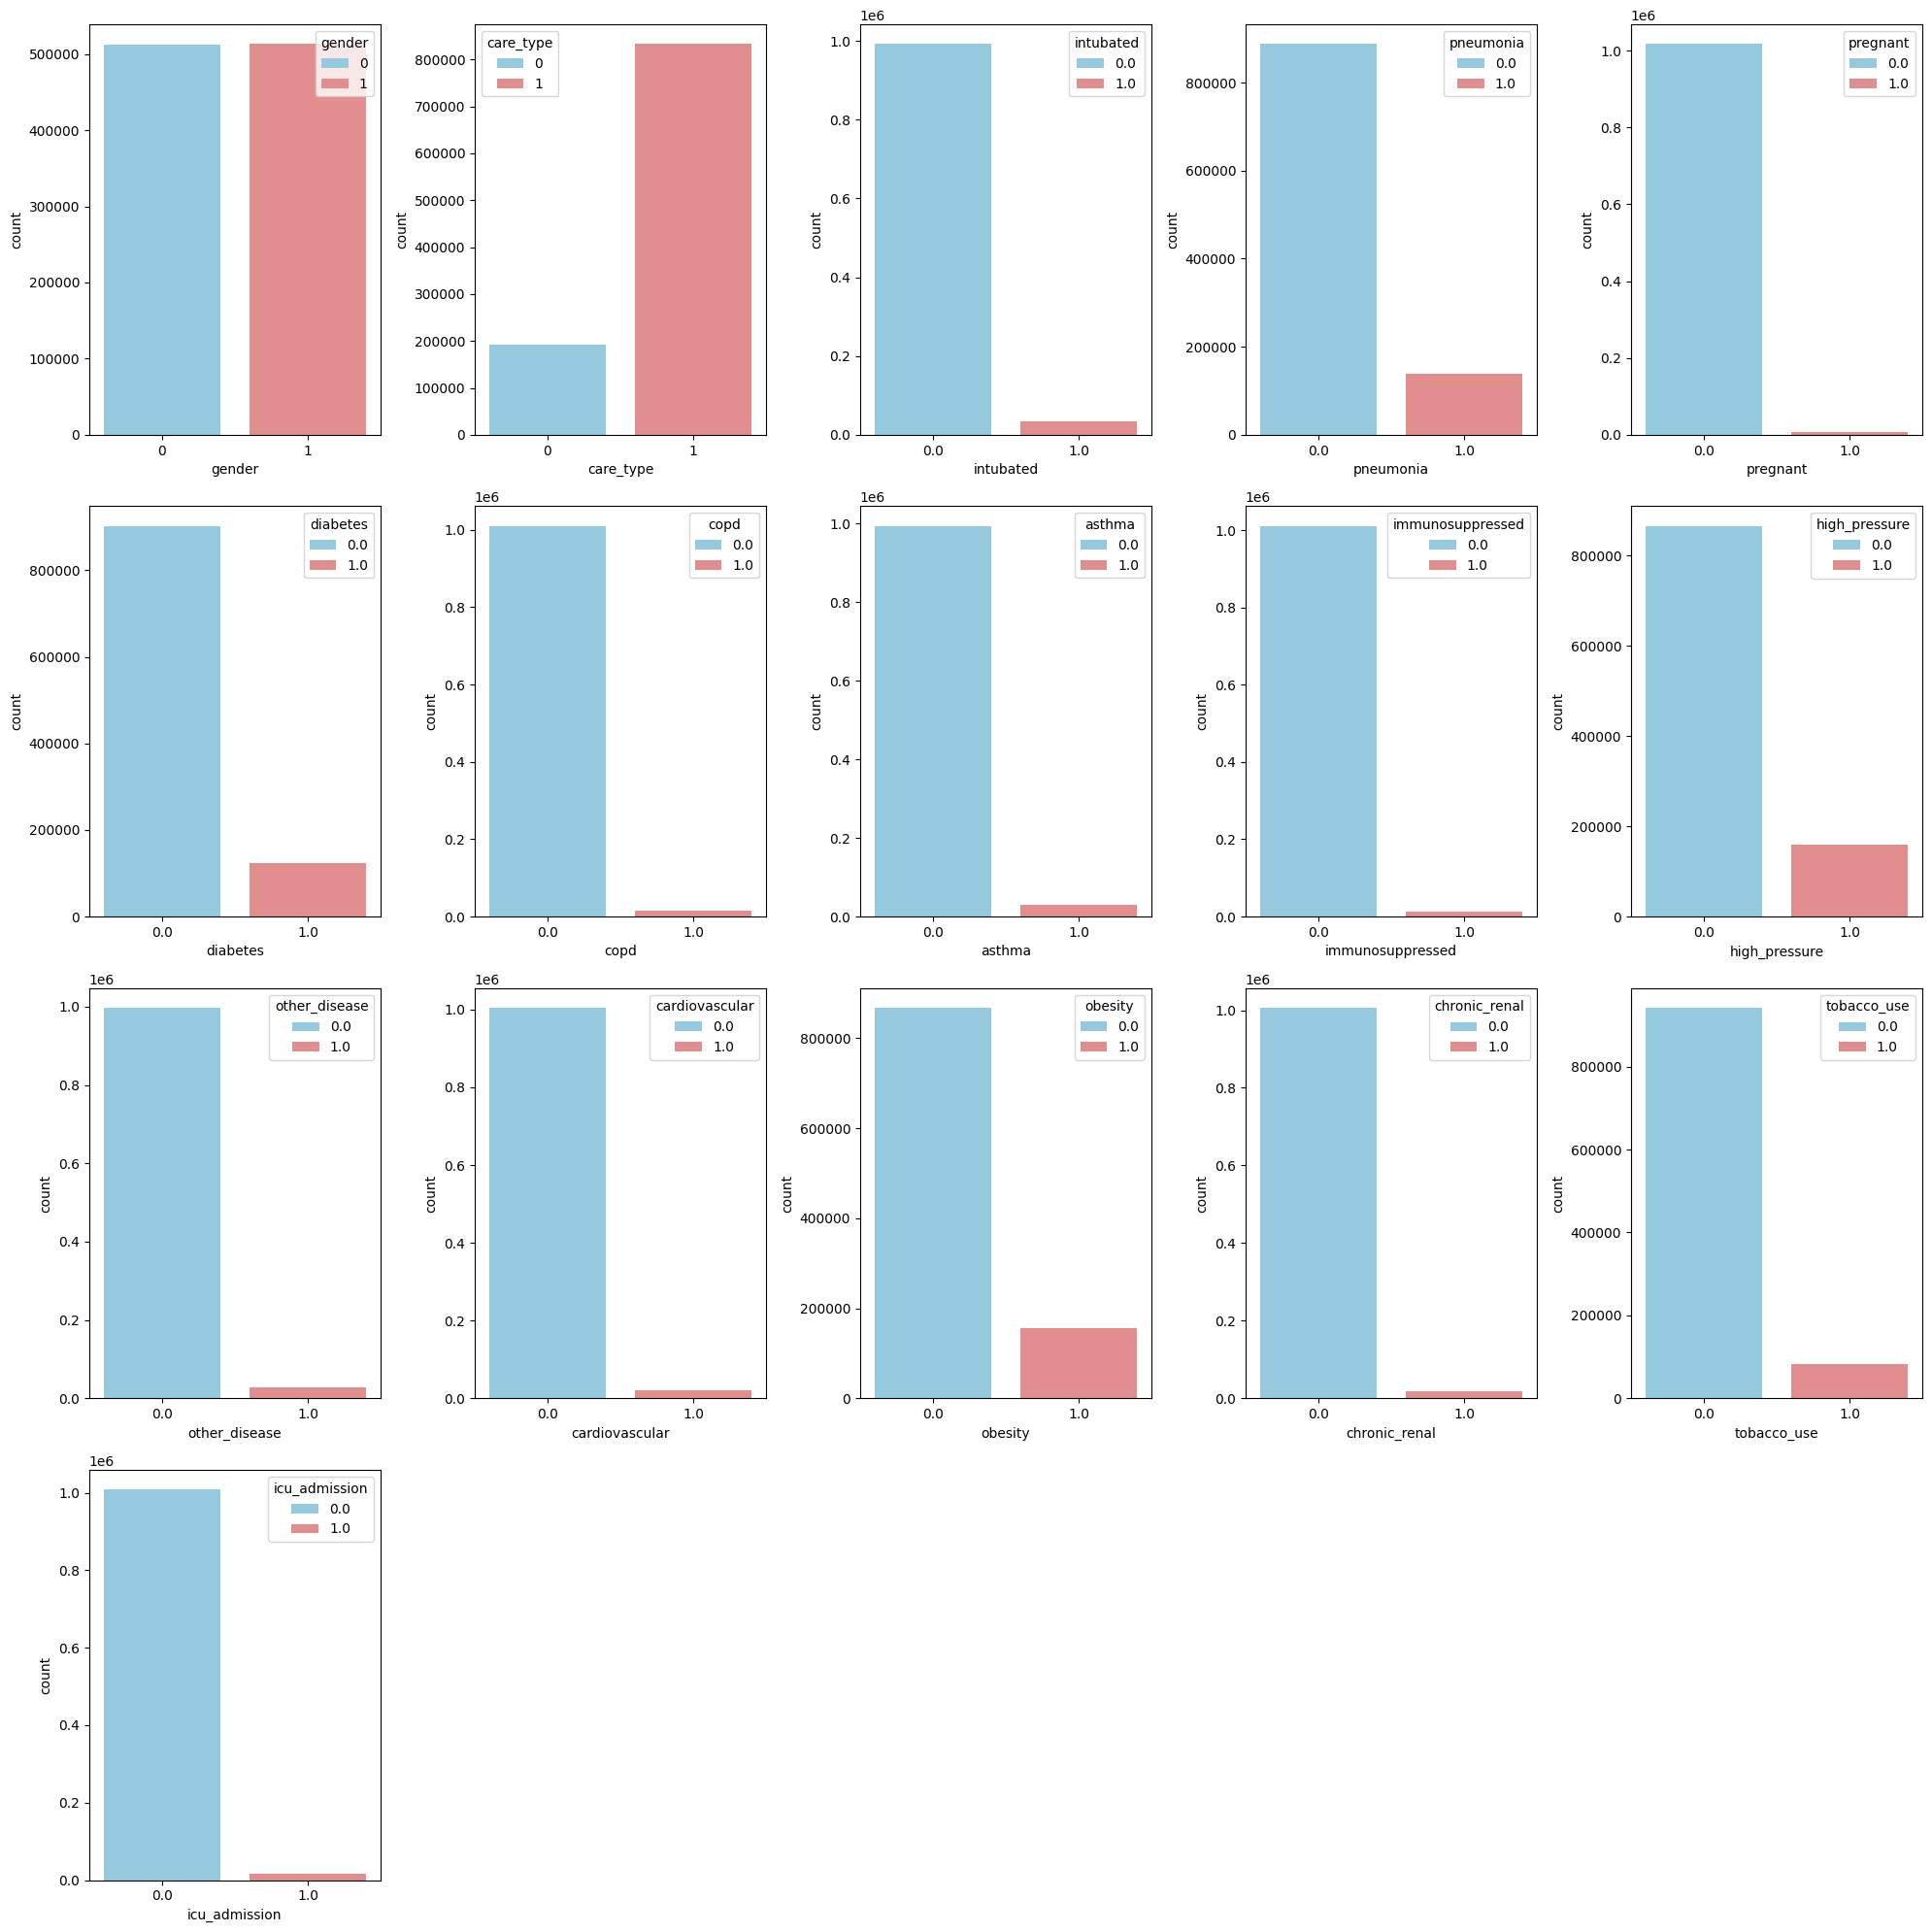

In [28]:
n = len (binary_cols)
COLUMNS = 5
rows = math.ceil (n / COLUMNS)

fig, axes = plt.subplots (rows, COLUMNS, figsize= (20, 5 * rows))
axes = axes.flatten ()

for i, col in enumerate (binary_cols):
    sns.countplot (data= df, x= df [col], ax= axes [i], palette= ["skyblue", "lightcoral"], hue=df[col])

for j in range (i + 1, len (axes)):
    fig.delaxes (axes [j])

plt.tight_layout ()
plt.show ()

DIED
0    950438
1     74714
Name: count, dtype: int64


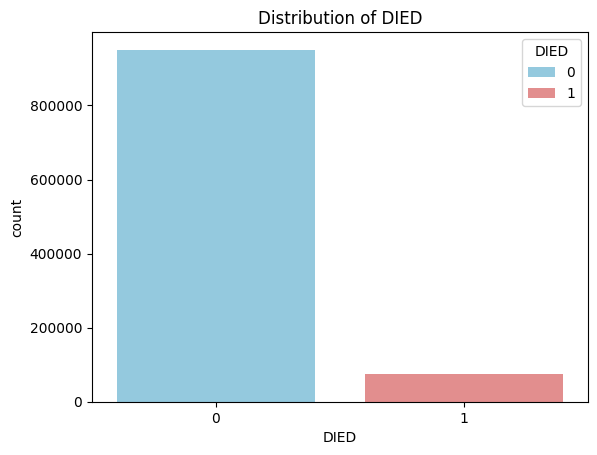

In [29]:
print (df ["DIED"].value_counts ())
sns.countplot (data=df, x= df ["DIED"], palette= ["skyblue", "lightcoral"], hue= df ["DIED"])
plt.title ("Distribution of DIED")
plt.show ()

### Outliers

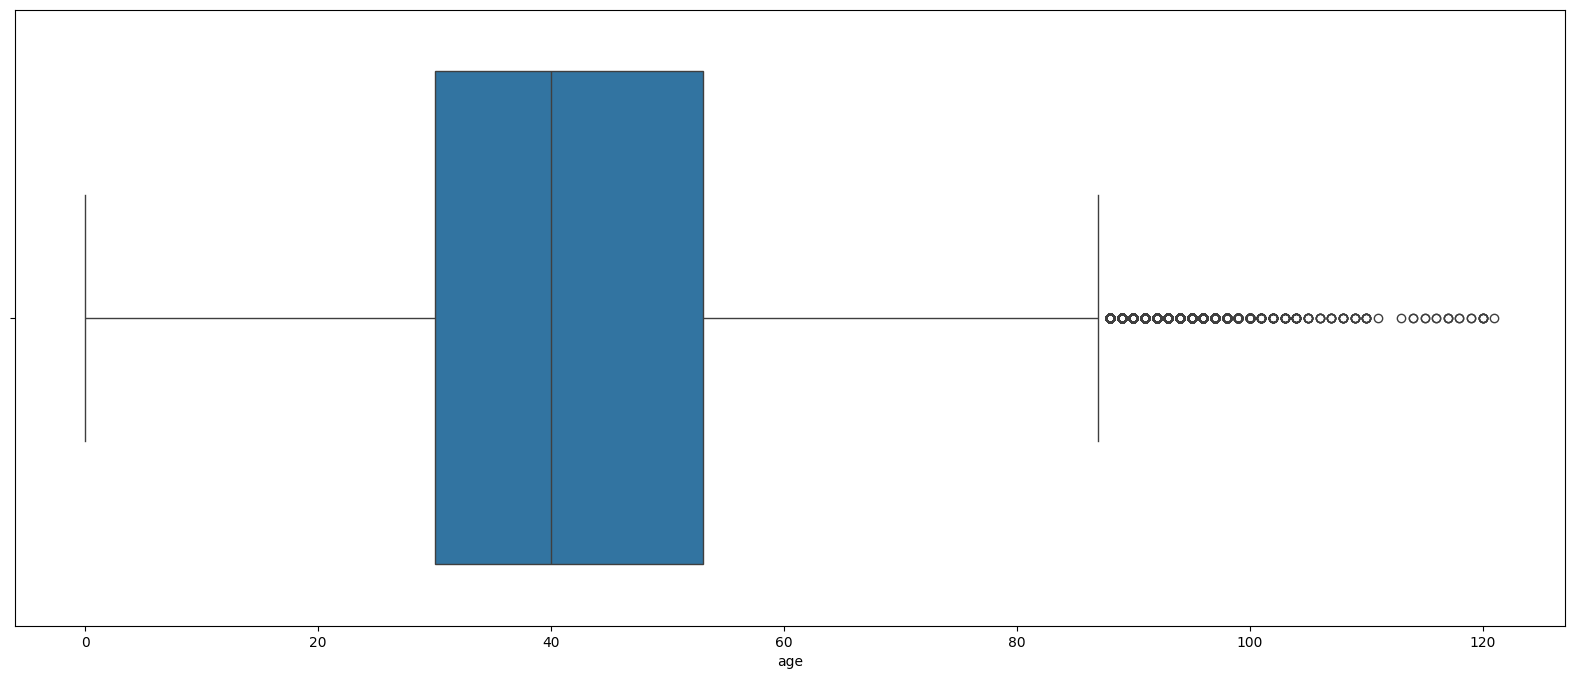

In [30]:
plt.figure (figsize= (20, 8))
sns.boxplot (data= df, x= df ["age"])
plt.show ()

In [31]:
print (df ["age"].max ())
print (df ["age"].min ())

121
0


In [32]:
(df ["age"] == 0).sum ()

np.int64(3780)

In [33]:
df = df [df ["age"] != 0]

In [34]:
print (df ["age"].max ())
print (df ["age"].min ())

121
1


### Relations

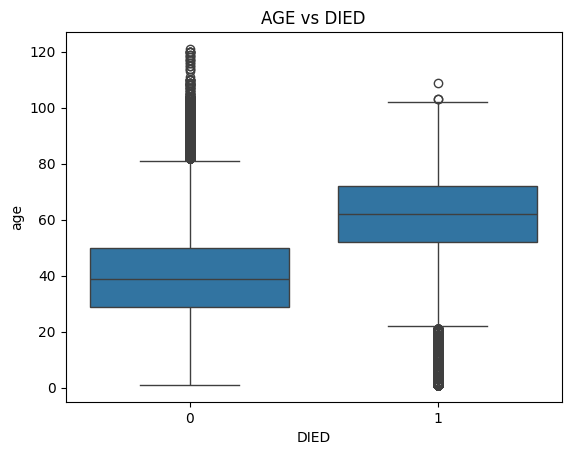

In [35]:
sns.boxplot (
    data=df,
    x= "DIED",
    y= "age"
)

plt.title ("AGE vs DIED")
plt.show ()

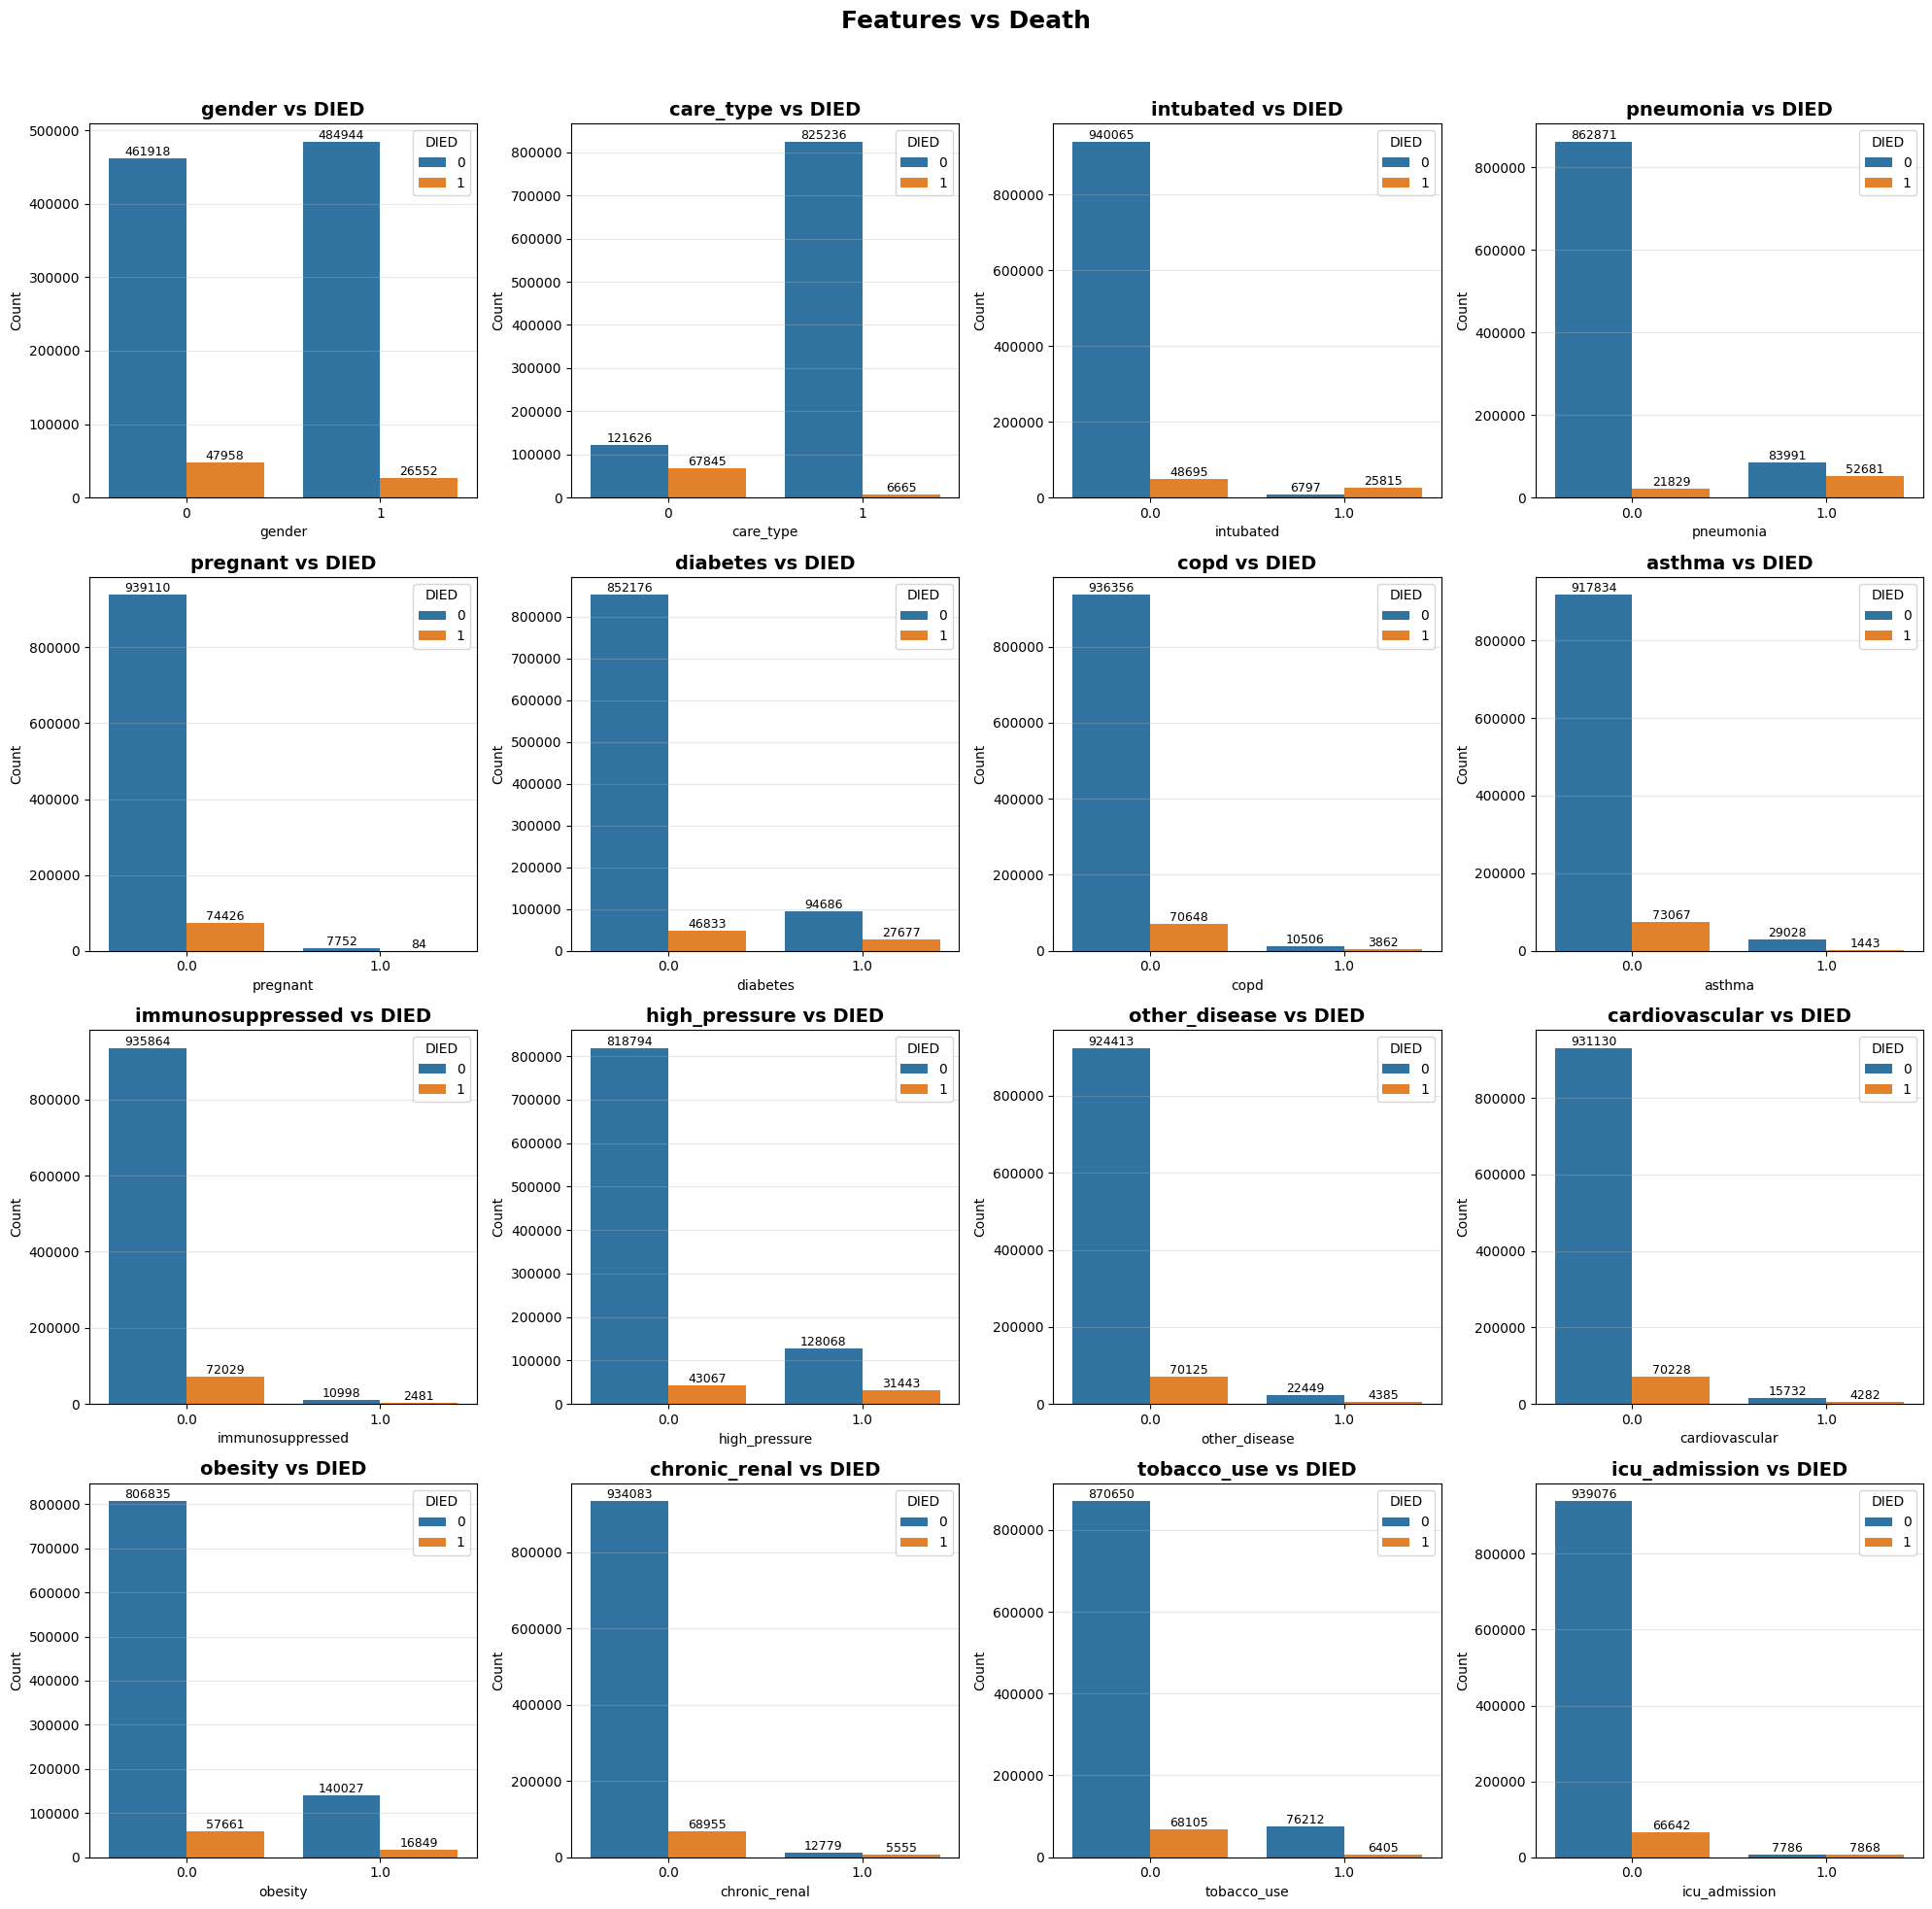

In [36]:
n = len (binary_cols)
COLUMNS = 4
rows = math.ceil (n / COLUMNS)

fig, axes = plt.subplots (
    rows,
    COLUMNS,
    figsize= (20, 5 * rows)
)

axes = axes.flatten ()

for i, feature in enumerate (binary_cols):
    ax = sns.countplot (
        data= df,
        x= feature,
        hue= "DIED",
        ax= axes [i]
    )

    axes [i].set_title (
        f"{feature} vs DIED",
        fontsize= 14,
        fontweight= "bold"
    )

    axes [i].set_xlabel (feature)
    axes [i].set_ylabel ("Count")

    axes [i].grid (
        axis= "y",
        alpha= 0.3
    )

    for container in ax.containers:
        ax.bar_label (
            container,
            fontsize= 9
        )

for j in range (n, len (axes)):
    fig.delaxes (axes [j])

plt.suptitle (
    "Features vs Death",
    fontsize= 18,
    fontweight= "bold"
)

plt.tight_layout  (rect= [0, 0, 1, 0.96])
plt.show ()

## Split the data

In [37]:
f_count = len (df.drop ("DIED", axis= 1).columns)
print ("Number of features:", f_count)

Number of features: 20


In [38]:
X = df.drop ("DIED", axis= 1)
y = df ['DIED']

In [39]:
print (y.value_counts ())

DIED
0    946862
1     74510
Name: count, dtype: int64


In [40]:
X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size= 0.2, random_state= 42, stratify= y
)

### Handle imbalance with SMOTE and SMOTENC

In [42]:
smote_nc = SMOTENC (
    categorical_features=binary_cols,
    random_state=42
)

X_train_resampled, y_train_resampled = smote_nc.fit_resample(
    X_train,
    y_train
)

In [43]:
y_train_resampled.value_counts ()

,count
DIED,
0,757489
1,757489


## Models

In [ ]:
groups = X_train ['medical_unit']

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    "max_depth": [3, 5, 8, 10, 12, 15]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=sgkf,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train, groups=groups)

print("Best max_depth:", rf_grid.best_params_["max_depth"])
print("Best CV F1:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"Test Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Test Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"Test F1:        {f1_score(y_test, y_pred_rf):.4f}")
print(f"Test ROC-AUC:   {auc(*roc_curve(y_test, y_proba_rf)[:2]):.4f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best max_depth: 12
Best CV F1: 0.5183285923713493
Test Accuracy:  0.8912
Test Precision: 0.3969
Test Recall:    0.9465
Test F1:        0.5592
Test ROC-AUC:   0.9665


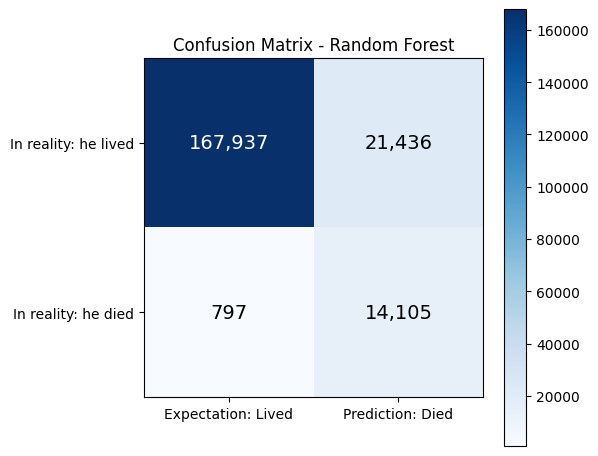

In [45]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure (figsize=(6,5))
plt.imshow (cm, cmap='Blues')
plt.colorbar ()
plt.xticks([0,1], ['Expectation: Lived', 'Prediction: Died'])
plt.yticks([0,1], ['In reality: he lived', 'In reality: he died'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=14,
                  color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout ()
plt.show ()

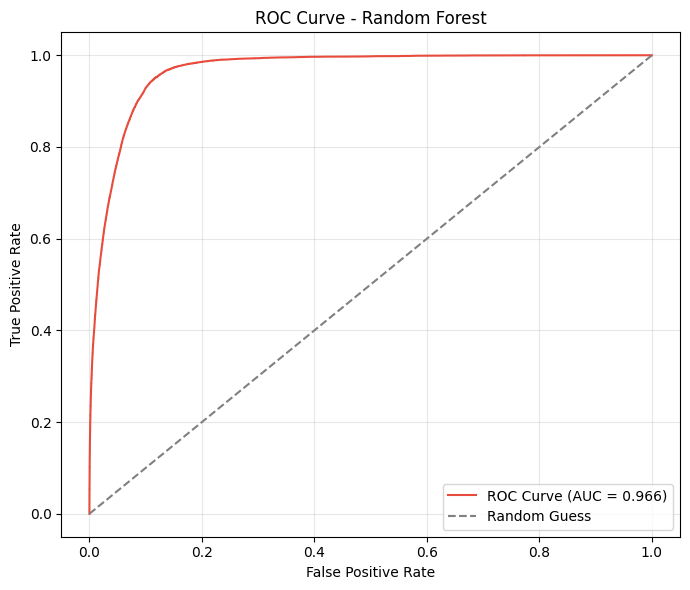

AUC Score: 0.9665


In [46]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_rf, tpr_rf, color='#e74c3c', label=f'ROC Curve (AUC = {roc_auc_rf:.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc_rf:.4f}")

In [47]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

print ("Threshold Results - Random Forest")
print ("="*75)
for t in thresholds:
    y_pred_t_rf = (y_proba_rf >= t).astype(int)
    acc_t_rf = accuracy_score(y_test, y_pred_t_rf)
    prec_t_rf = precision_score(y_test, y_pred_t_rf, zero_division=0)
    rec_t_rf = recall_score(y_test, y_pred_t_rf, zero_division=0)
    f1_t_rf = f1_score(y_test, y_pred_t_rf, zero_division=0)
    print(f"Threshold: {t:.2f} | Accuracy: {acc_t_rf:.4f} | Precision: {prec_t_rf:.4f} | Recall: {rec_t_rf:.4f} | F1: {f1_t_rf:.4f}")

Threshold Results - Random Forest
Threshold: 0.30 | Accuracy: 0.8608 | Precision: 0.3409 | Recall: 0.9723 | F1: 0.5048
Threshold: 0.35 | Accuracy: 0.8696 | Precision: 0.3554 | Recall: 0.9675 | F1: 0.5198
Threshold: 0.40 | Accuracy: 0.8772 | Precision: 0.3689 | Recall: 0.9608 | F1: 0.5331
Threshold: 0.45 | Accuracy: 0.8849 | Precision: 0.3837 | Recall: 0.9532 | F1: 0.5472
Threshold: 0.50 | Accuracy: 0.8912 | Precision: 0.3969 | Recall: 0.9465 | F1: 0.5592


In [48]:
import joblib
import os

# model_dir = './drive/MyDrive/Projects/covid_19/models'
model_dir = './'
os.makedirs (model_dir, exist_ok=True)

joblib.dump (best_rf, os.path.join(model_dir, 'random_forest_model.joblib'))

print (f"Random Forest model saved to: {os.path.join(model_dir, 'random_forest_model.joblib')}")

Random Forest model saved to: ./random_forest_model.joblib


In [49]:
# from sklearn.tree import DecisionTreeClassifier

# dt = DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced')
# dt.fit(X_train_resampled, y_train_resampled)


# y_pred_dt = dt.predict(X_test)
# y_proba_dt = dt.predict_proba(X_test)[:,1]

# print("=== Decision Tree ===")
# print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.2f}")
# print(f"Precision: {precision_score(y_test, y_pred_dt):.2f}")
# print(f"Recall:    {recall_score(y_test, y_pred_dt):.2f}")
# print(f"F1 Score:  {f1_score(y_test, y_pred_dt):.2f}")
# print(f"ROC-AUC:   {auc(*roc_curve(y_test, y_proba_dt)[:2]):.2f}")

In [50]:
# cm_dt = confusion_matrix(y_test, y_pred_dt)

# plt.figure (figsize=(6,5))
# plt.imshow (cm_dt, cmap='Blues')
# plt.colorbar ()
# plt.xticks([0,1], ['Expectation: Lived', 'Prediction: Died'])
# plt.yticks([0,1], ['In reality: he lived', 'In reality: he died'])
# for i in range(2):
#     for j in range(2):
#         plt.text(j, i, f'{cm_dt[i,j]:,}', ha='center', va='center', fontsize=14,
#                   color='white' if cm_dt[i,j] > cm_dt.max()/2 else 'black')
# plt.title('Confusion Matrix - Decision Tree')
# plt.tight_layout ()
# plt.show ()

In [51]:
# fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
# roc_auc_dt = auc(fpr_dt, tpr_dt)

# plt.figure(figsize=(7,6))
# plt.plot(fpr_dt, tpr_dt, color='#2ecc71', label=f'ROC Curve (AUC = {roc_auc_dt:.3f})')
# plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve - Decision Tree')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# print(f"AUC Score: {roc_auc_dt:.4f}")

In [52]:
# thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

# print ("Threshold Results - Decision Tree")
# print ("="*75)
# for t in thresholds:
#     y_pred_t_dt = (y_proba_dt >= t).astype(int)
#     acc_t_dt = accuracy_score(y_test, y_pred_t_dt)
#     prec_t_dt = precision_score(y_test, y_pred_t_dt, zero_division=0)
#     rec_t_dt = recall_score(y_test, y_pred_t_dt, zero_division=0)
#     f1_t_dt = f1_score(y_test, y_pred_t_dt, zero_division=0)
#     print(f"Threshold: {t:.2f} | Accuracy: {acc_t_dt:.4f} | Precision: {prec_t_dt:.4f} | Recall: {rec_t_dt:.4f} | F1: {f1_t_dt:.4f}")

In [53]:
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline

# knn_pipe = make_pipeline(
#     StandardScaler(),
#     KNeighborsClassifier(
#         n_neighbors=5,
#         weights="distance"
#     )
# )

# knn_pipe.fit(X_train_resampled, y_train_resampled)

# y_pred_knn = knn_pipe.predict(X_test)
# y_proba_knn = knn_pipe.predict_proba(X_test)[:, 1]

# acc_knn = accuracy_score(y_test, y_pred_knn)
# prec_knn = precision_score(y_test, y_pred_knn, zero_division=0)
# rec_knn = recall_score(y_test, y_pred_knn, zero_division=0)
# f1_knn = f1_score(y_test, y_pred_knn, zero_division=0)
# fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
# roc_auc_knn = auc(fpr_knn, tpr_knn)

# print("=== KNN ===")
# print(f"Accuracy:  {acc_knn:.4f}")
# print(f"Precision: {prec_knn:.4f}")
# print(f"Recall:    {rec_knn:.4f}")
# print(f"F1 Score:  {f1_knn:.4f}")
# print(f"ROC-AUC:   {roc_auc_knn:.4f}")
# print()
# print(classification_report(y_test, y_pred_knn, target_names=['Alive', 'Died']))

In [54]:
# cm_knn = confusion_matrix(y_test, y_pred_knn)

# plt.figure (figsize=(6,5))
# plt.imshow (cm_knn, cmap='Blues')
# plt.colorbar ()
# plt.xticks([0,1], ['Expectation: Lived', 'Prediction: Died'])
# plt.yticks([0,1], ['In reality: he lived', 'In reality: he died'])
# for i in range(2):
#     for j in range(2):
#         plt.text(j, i, f'{cm_knn[i,j]:,}', ha='center', va='center', fontsize=14,
#                   color='white' if cm_knn[i,j] > cm_knn.max()/2 else 'black')
# plt.title('Confusion Matrix - KNN')
# plt.tight_layout ()
# plt.show ()

In [55]:
# fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
# roc_auc_knn = auc(fpr_knn, tpr_knn)

# plt.figure(figsize=(7,6))
# plt.plot(fpr_knn, tpr_knn, color='#e74c3c', label=f'ROC Curve (AUC = {roc_auc_knn:.3f})')
# plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve - KNN')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# print(f"AUC Score: {roc_auc_knn:.4f}")

In [56]:
# thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

# print ("Threshold Results - KNN")
# print ("="*75)
# for t in thresholds:
#     y_pred_t_knn = (y_proba_knn >= t).astype(int)
#     acc_t_knn = accuracy_score(y_test, y_pred_t_knn)
#     prec_t_knn = precision_score(y_test, y_pred_t_knn, zero_division=0)
#     rec_t_knn = recall_score(y_test, y_pred_t_knn, zero_division=0)
#     f1_t_knn = f1_score(y_test, y_pred_t_knn, zero_division=0)
#     print(f"Threshold: {t:.2f} | Accuracy: {acc_t_knn:.4f} | Precision: {prec_t_knn:.4f} | Recall: {rec_t_knn:.4f} | F1: {f1_t_knn:.4f}")

In [57]:
# cm = confusion_matrix(y_test, y_pred)

# plt.figure (figsize=(6,5))
# plt.imshow (cm, cmap='Blues')
# plt.colorbar ()
# plt.xticks([0,1], ['Expectation: Lived', 'Prediction: Died'])
# plt.yticks([0,1], ['In reality: he lived', 'In reality: he died'])
# for i in range(2):
#     for j in range(2):
#         plt.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=14,
#                   color='white' if cm[i,j] > cm.max()/2 else 'black')
# plt.title('Confusion Matrix')
# plt.tight_layout ()
# plt.show ()

In [58]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline

# log_pipe = make_pipeline(
#     StandardScaler(),
#     LogisticRegression(solver="saga", max_iter=1000, random_state=42)
# )

# log_pipe.fit(X_train_resampled, y_train_resampled)

# y_pred_log = log_pipe.predict(X_test)
# y_proba_log = log_pipe.predict_proba(X_test)[:, 1]

# print("=== Logistic Regression ===")
# print(f"Accuracy:  {accuracy_score(y_test, y_pred_log):.4f}")
# print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
# print(f"Recall:    {recall_score(y_test, y_pred_log):.4f}")
# print(f"F1 Score:  {f1_score(y_test, y_pred_log):.4f}")
# print(f"ROC-AUC:   {auc(*roc_curve(y_test, y_proba_log)[:2]):.4f}")

# # ROC curve
# fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
# plt.figure(figsize=(7,6))
# plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc(fpr_log, tpr_log):.3f})', color='#2c7fb8')
# plt.plot([0,1], [0,1], linestyle='--', color='gray')
# plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
# plt.title('ROC Curve - Logistic Regression'); plt.legend(); plt.grid(alpha=0.3)
# plt.tight_layout(); plt.show()

In [59]:
# cm_log = confusion_matrix(y_test, y_pred_log)

# plt.figure (figsize=(6,5))
# plt.imshow (cm_log, cmap='Blues')
# plt.colorbar ()
# plt.xticks([0,1], ['Expectation: Lived', 'Prediction: Died'])
# plt.yticks([0,1], ['In reality: he lived', 'In reality: he died'])
# for i in range(2):
#     for j in range(2):
#         plt.text(j, i, f'{cm_log[i,j]:,}', ha='center', va='center', fontsize=14,
#                   color='white' if cm_log[i,j] > cm_log.max()/2 else 'black')
# plt.title('Confusion Matrix - Logistic Regression')
# plt.tight_layout ()
# plt.show ()

In [60]:
# fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
# roc_auc_log = auc(fpr_log, tpr_log)

# plt.figure(figsize=(7,6))
# plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.3f})', color='#2c7fb8')
# plt.plot([0,1], [0,1], linestyle='--', color='gray')
# plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
# plt.title('ROC Curve - Logistic Regression'); plt.legend(); plt.grid(alpha=0.3)
# plt.tight_layout(); plt.show()

# print(f"AUC Score: {roc_auc_log:.4f}")

In [61]:
# thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

# print ("Threshold Results - Logistic Regression")
# print ("="*75)
# for t in thresholds:
#     y_pred_t_log = (y_proba_log >= t).astype(int)
#     acc_t_log = accuracy_score(y_test, y_pred_t_log)
#     prec_t_log = precision_score(y_test, y_pred_t_log, zero_division=0)
#     rec_t_log = recall_score(y_test, y_pred_t_log, zero_division=0)
#     f1_t_log = f1_score(y_test, y_pred_t_log, zero_division=0)
#     print(f"Threshold: {t:.2f} | Accuracy: {acc_t_log:.4f} | Precision: {prec_t_log:.4f} | Recall: {rec_t_log:.4f} | F1: {f1_t_log:.4f}")

In [62]:
# from sklearn.svm import SVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline

# # SVM can be computationally intensive, especially with a large dataset.
# # Using a linear kernel and a reasonable number of iterations for demonstration.
# # For a full model, hyperparameter tuning and potentially subsampling might be needed.
# svm_pipe = make_pipeline(
#     StandardScaler(),
#     SVC(
#         kernel='linear',
#         probability=True, # Required for roc_curve and predict_proba
#         random_state=42,
#         class_weight='balanced',
#         max_iter=1000 # Limit iterations for faster execution
#     )
# )

# print("Training SVM... (This might take some time due to dataset size and complexity)")
# svm_pipe.fit(X_train_resampled, y_train_resampled)

# y_pred_svm = svm_pipe.predict(X_test)
# y_proba_svm = svm_pipe.predict_proba(X_test)[:, 1]

# print("=== Support Vector Machine ===")
# print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
# print(f"Precision: {precision_score(y_test, y_pred_svm, zero_division=0):.4f}")
# print(f"Recall:    {recall_score(y_test, y_pred_svm, zero_division=0):.4f}")
# print(f"F1 Score:  {f1_score(y_test, y_pred_svm, zero_division=0):.4f}")
# print(f"ROC-AUC:   {auc(*roc_curve(y_test, y_proba_svm)[:2]):.4f}")

In [63]:
# cm_svm = confusion_matrix(y_test, y_pred_svm)

# plt.figure (figsize=(6,5))
# plt.imshow (cm_svm, cmap='Blues')
# plt.colorbar ()
# plt.xticks([0,1], ['Expectation: Lived', 'Prediction: Died'])
# plt.yticks([0,1], ['In reality: he lived', 'In reality: he died'])
# for i in range(2):
#     for j in range(2):
#         plt.text(j, i, f'{cm_svm[i,j]:,}', ha='center', va='center', fontsize=14,
#                   color='white' if cm_svm[i,j] > cm_svm.max()/2 else 'black')
# plt.title('Confusion Matrix - Support Vector Machine')
# plt.tight_layout ()
# plt.show ()

In [64]:
# fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
# roc_auc_svm = auc(fpr_svm, tpr_svm)

# plt.figure(figsize=(7,6))
# plt.plot(fpr_svm, tpr_svm, color='#9b59b6', label=f'ROC Curve (AUC = {roc_auc_svm:.3f})')
# plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve - Support Vector Machine')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# print(f"AUC Score: {roc_auc_svm:.4f}")

In [65]:
# thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

# print ("Threshold Results - Support Vector Machine")
# print ("="*75)
# for t in thresholds:
#     y_pred_t_svm = (y_proba_svm >= t).astype(int)
#     acc_t_svm = accuracy_score(y_test, y_pred_t_svm)
#     prec_t_svm = precision_score(y_test, y_pred_t_svm, zero_division=0)
#     rec_t_svm = recall_score(y_test, y_pred_t_svm, zero_division=0)
#     f1_t_svm = f1_score(y_test, y_pred_t_svm, zero_division=0)
#     print(f"Threshold: {t:.2f} | Accuracy: {acc_t_svm:.4f} | Precision: {prec_t_svm:.4f} | Recall: {rec_t_svm:.4f} | F1: {f1_t_svm:.4f}")